# Wine Quality Classification

## Part 1: Loading the Dataset

### Objective

The objective of this project is to explore the Wine dataset and develop machine learning models to classify different types of wine based on their chemical characteristics.

In [1]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()

# Create a DataFrame
data = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Add the target variable
data["target"] = wine.target

# Display the first five rows
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Key Observation

The Wine dataset was successfully loaded into a Pandas DataFrame. It contains multiple numerical features representing the chemical characteristics of different wine samples.

The target variable represents three different wine classes, making this a multi-class classification problem.

## Part 2: Dataset Inspection and Data Quality Analysis

### Objective


This section examines the structure and quality of the Wine dataset. The analysis includes checking the dataset dimensions, data types, missing values, and summary statistics of the numerical features.

In [2]:
# Display dataset dimensions
print("Dataset Shape:", data.shape)

# Display dataset information
print("\nDataset Information:")
data.info()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
display(data.describe())

Dataset Shape: (178, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline          

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Key Observation

The Wine dataset contains multiple numerical features representing the chemical characteristics of wine samples, along with a target variable representing the wine class.

The dataset contains no missing values, making it suitable for machine learning analysis without requiring additional missing-value treatment. The summary statistics also show that the numerical features have different ranges and distributions.

## Part 3: Exploratory Data Visualisation

### Objective

This section uses visualisation techniques to explore the distributions of selected chemical characteristics and identify patterns within the Wine dataset.

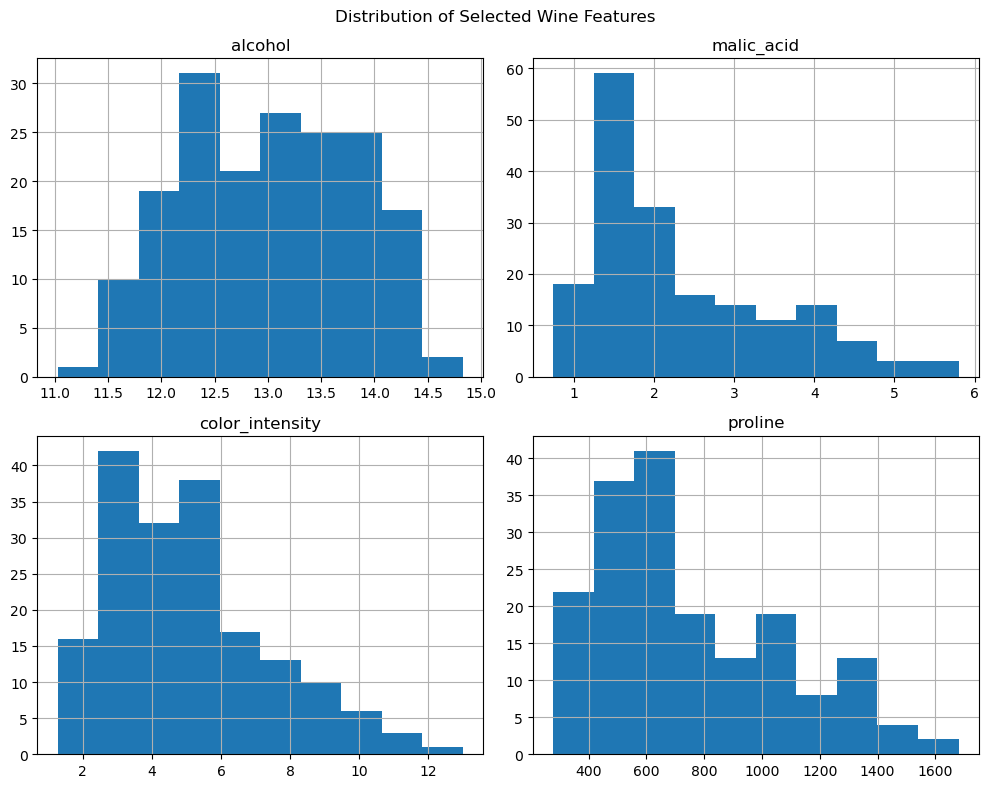

In [3]:
import matplotlib.pyplot as plt

# Plot histograms for selected features
selected_features = [
    "alcohol",
    "malic_acid",
    "color_intensity",
    "proline"
]

data[selected_features].hist(figsize=(10, 8))

plt.suptitle("Distribution of Selected Wine Features")
plt.tight_layout()
plt.show()

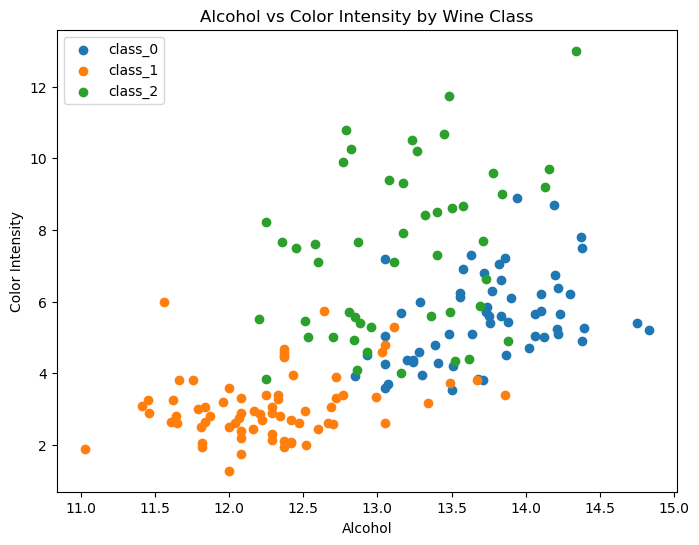

In [4]:
plt.figure(figsize=(8, 6))

for target in data["target"].unique():
    subset = data[data["target"] == target]

    plt.scatter(
        subset["alcohol"],
        subset["color_intensity"],
        label=wine.target_names[target]
    )

plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.title("Alcohol vs Color Intensity by Wine Class")
plt.legend()

plt.show()

### Key Observation

The visualisations show that the chemical characteristics of wine samples have different distributions and ranges.

The scatter plot demonstrates that features such as alcohol content and colour intensity can help distinguish between different wine classes. Some classes form more clearly separated groups, indicating that these chemical characteristics may be useful for classification.

## Part 4: Wine Class Distribution Analysis

### Objective

This section examines the distribution of observations across the different wine classes. Understanding the class distribution is important for determining whether the dataset is balanced and suitable for classification modelling.

In [5]:
# Count the number of observations in each wine class
class_counts = data["target"].value_counts().sort_index()

# Create a DataFrame with class names
class_distribution = pd.DataFrame({
    "Wine Class": wine.target_names,
    "Number of Samples": class_counts.values
})

display(class_distribution)

,Wine Class,Number of Samples
0,class_0,59
1,class_1,71
2,class_2,48


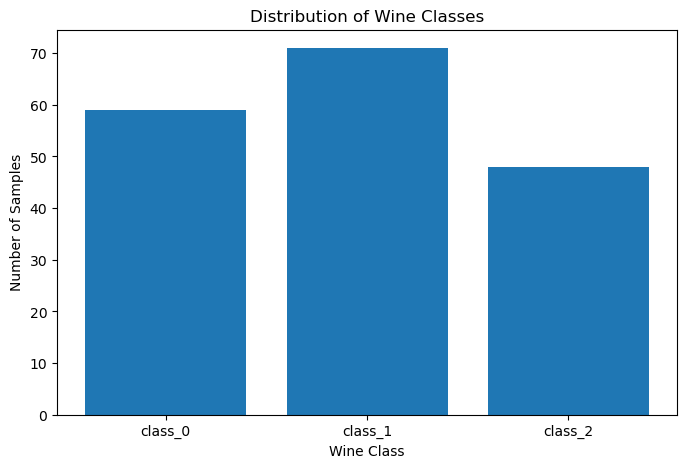

In [6]:
plt.figure(figsize=(8, 5))

plt.bar(
    wine.target_names,
    class_counts.values
)

plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Wine Classes")

plt.show()

### Key Observation

The Wine dataset contains observations from three different wine classes. Examining the class distribution helps determine whether the dataset has a relatively balanced representation of each class.

A reasonably balanced class distribution is beneficial when developing classification models because it reduces the risk of the model being biased towards one particular class.

## Part 5: Data Preparation and Train-Test Split

### Objective

This section prepares the Wine dataset for machine learning by separating the input features from the target variable. The dataset is then divided into training and testing sets, and feature scaling is applied to standardise the numerical variables.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = data.drop("target", axis=1)
y = data["target"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (142, 13)
Testing data shape: (36, 13)


### Key Observation

The dataset was successfully divided into training and testing sets while preserving the distribution of the three wine classes.

Feature scaling was applied to standardise the numerical variables. This preparation step ensures that features with larger numerical ranges do not have an unnecessary influence on machine learning models.

## Part 6: Wine Classification Model

### Objective

This section develops a Logistic Regression model to classify wine samples into their respective classes based on their chemical characteristics.

In [8]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
# Predict wine classes using the test data
y_pred = model.predict(X_test_scaled)

# Display some predictions
results = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred
})

results.head(10)

,Actual Class,Predicted Class
0,0,0
1,2,1
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,2,2


### Key Observation

The Logistic Regression model was successfully trained using the scaled training data.

The model can now predict the wine class of previously unseen samples based on their chemical characteristics. The next section will evaluate how accurately these predictions match the actual wine classes.

## Part 7: Model Evaluation

### Objective

This section evaluates the performance of the Logistic Regression model using unseen test data. Classification metrics are used to measure how accurately the model predicts the different wine classes.

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Display the classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.9722222222222222

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


### Key Observation

The Logistic Regression model was evaluated using unseen test data.

The accuracy score provides an overall measure of the model's classification performance, while the classification report provides detailed precision, recall, and F1-score values for each wine class.

The confusion matrix shows the number of correct predictions and any misclassifications between the three wine classes.

## Part 8: Comparing Multiple Classification Models

### Objective

This section compares the performance of different machine learning algorithms on the Wine dataset. Logistic Regression, K-Nearest Neighbours, and Random Forest models are evaluated using the same training and testing data.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Create additional models
knn_model = KNeighborsClassifier(n_neighbors=5)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the models
knn_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

# Compare model accuracy
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

# Sort by accuracy
model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)

display(model_results)

,Model,Accuracy
2,Random Forest,1.000000
0,Logistic Regression,0.972222
1,K-Nearest Neighbours,0.972222


### Key Observation

Comparing multiple machine learning models provides a broader understanding of the Wine classification problem.

Different algorithms may produce different results because they identify patterns in the data using different approaches. Comparing their accuracy helps identify which model performs best on the unseen test data.

## Part 9: Feature Importance Analysis

### Objective

This section examines which chemical characteristics are most influential in distinguishing between the different wine classes. Random Forest feature importance is used to identify the variables that contribute most strongly to the classification process.

In [12]:
# Extract feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
9,color_intensity,0.187580
6,flavanoids,0.159561
12,proline,0.146799
0,alcohol,0.117913
10,hue,0.101538
11,od280/od315_of_diluted_wines,0.096301
5,total_phenols,0.041514
4,magnesium,0.040131
1,malic_acid,0.033894
3,alcalinity_of_ash,0.025471


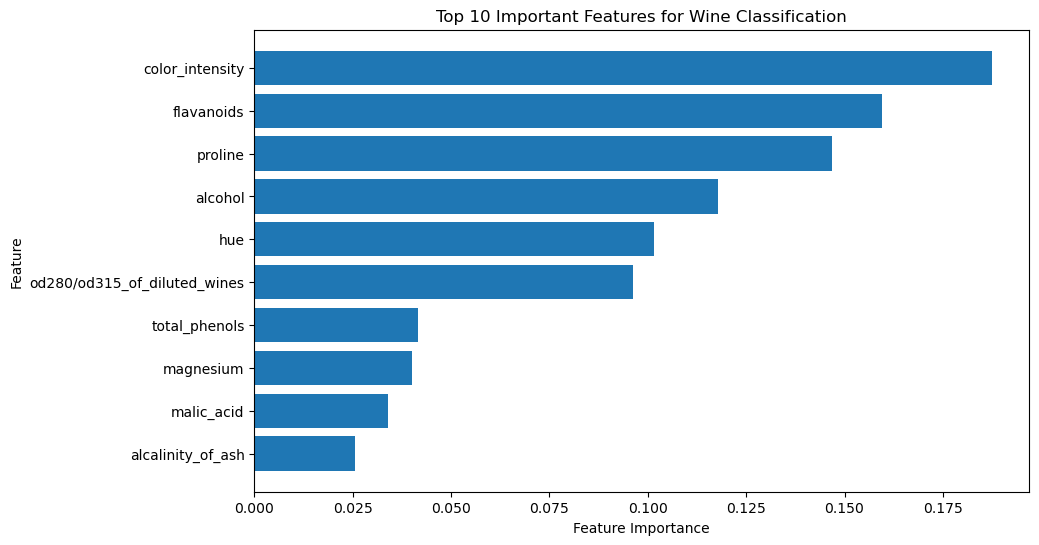

In [13]:
# Display the top 10 most important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features for Wine Classification")

plt.gca().invert_yaxis()

plt.show()

### Key Observation

The feature importance analysis identifies the chemical characteristics that contribute most strongly to the Random Forest classification model.

Features with higher importance scores have a greater influence on distinguishing between the different wine classes. This analysis provides additional insight into which chemical properties are most useful for wine classification.

## Part 10: Confusion Matrix Visualisation

### Objective

This section visualises the confusion matrix of the Logistic Regression model. A graphical representation makes it easier to understand the number of correct and incorrect predictions for each wine class.

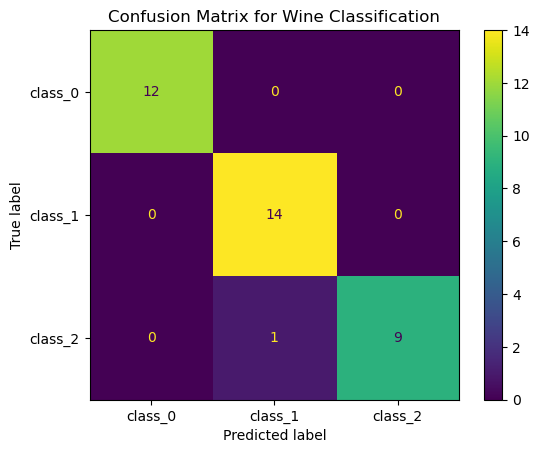

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a confusion matrix visualisation
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=wine.target_names
)

plt.title("Confusion Matrix for Wine Classification")
plt.show()

### Key Observation

The confusion matrix provides a detailed view of the model's predictions for each wine class.

Correct predictions are represented along the main diagonal of the matrix, while incorrect predictions appear outside the diagonal. This visualisation helps identify which wine classes are classified accurately and where misclassifications occur.

## Part 11: Hyperparameter Tuning

### Objective

This section investigates how different values of the K-Nearest Neighbours hyperparameter `n_neighbors` affect classification performance.

Multiple values of K are tested to identify the configuration that achieves the highest accuracy on the test dataset.

In [15]:
# Test different K values
k_values = range(1, 16)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    # Make predictions
    predictions = knn.predict(X_test_scaled)

    # Calculate and store accuracy
    accuracy_scores.append(
        accuracy_score(y_test, predictions)
    )

# Create a DataFrame with the results
tuning_results = pd.DataFrame({
    "Number of Neighbors (K)": list(k_values),
    "Accuracy": accuracy_scores
})

display(tuning_results)

,Number of Neighbors (K),Accuracy
0,1,0.972222
1,2,0.944444
2,3,0.972222
3,4,0.944444
4,5,0.972222
5,6,0.972222
6,7,1.000000
7,8,1.000000
8,9,1.000000
9,10,1.000000


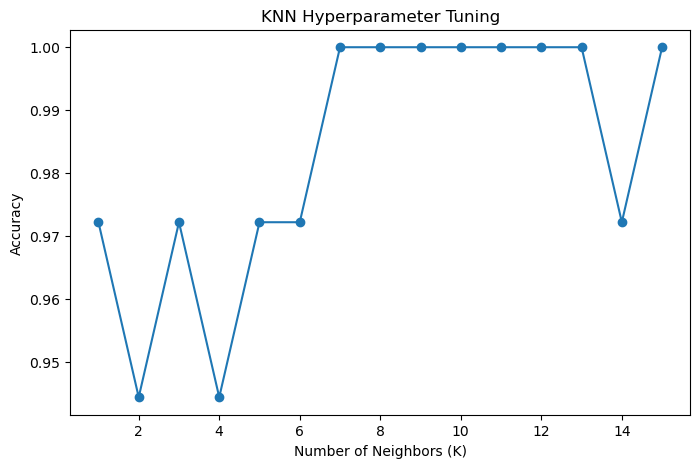

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    tuning_results["Number of Neighbors (K)"],
    tuning_results["Accuracy"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Tuning")

plt.show()

In [17]:
best_k = tuning_results.loc[
    tuning_results["Accuracy"].idxmax(),
    "Number of Neighbors (K)"
]

best_accuracy = tuning_results["Accuracy"].max()

print("Best K value:", best_k)
print("Best Accuracy:", round(best_accuracy, 4))

Best K value: 7
Best Accuracy: 1.0


### Key Observation

The results demonstrate that the performance of the K-Nearest Neighbours model changes depending on the selected value of K.

The value that achieves the highest accuracy represents the best-performing configuration among the tested values. This demonstrates the importance of hyperparameter tuning when developing machine learning models.

## Part 12: Final Model Performance Summary

### Objective

This section summarises the performance of the different machine learning models developed throughout the Wine Classification project and identifies the best-performing model based on test accuracy.

In [18]:
# Create a final comparison of all models

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

# Sort models by accuracy
final_results = final_results.sort_values(
    by="Accuracy",
    ascending=False
)

display(final_results)

,Model,Accuracy
2,Random Forest,1.000000
0,Logistic Regression,0.972222
1,K-Nearest Neighbours,0.972222


In [19]:
# Identify the best-performing model

best_model = final_results.iloc[0]

print("Best Performing Model:", best_model["Model"])
print("Best Accuracy:", round(best_model["Accuracy"], 4))

Best Performing Model: Random Forest
Best Accuracy: 1.0


### Key Observation

The final model comparison provides a clear overview of the performance of the different machine learning algorithms.

The best-performing model is identified based on its accuracy on the unseen test dataset. Comparing multiple models demonstrates that different algorithms can achieve different levels of performance when applied to the same classification problem.

## Part 13: Conclusion and Future Improvements

### Project Summary

This project explored the Wine dataset and developed several machine learning models to classify wine samples based on their chemical characteristics.

The analysis began with loading and inspecting the dataset, followed by data quality analysis and exploratory visualisation. The distribution of the wine classes was also examined before preparing the data for machine learning.

The dataset was divided into training and testing sets, and feature scaling was applied. Logistic Regression, K-Nearest Neighbours, and Random Forest models were trained and evaluated using the same test dataset.

Additional analysis included feature importance, confusion matrix visualisation, and hyperparameter tuning. Finally, the performance of the different models was compared to identify the best-performing approach.

### Future Improvements

Potential improvements for future work include:

- Testing additional machine learning algorithms.
- Using cross-validation for a more robust evaluation.
- Performing advanced hyperparameter tuning with GridSearchCV.
- Exploring feature selection techniques.
- Investigating additional evaluation metrics.
- Applying dimensionality reduction techniques such as PCA.

### Final Conclusion

This project demonstrates a complete machine learning workflow, from data exploration and preparation to model development, evaluation, and comparison.

The results show that chemical characteristics can be effectively used to distinguish between different wine classes. The project also demonstrates the importance of comparing multiple machine learning models and optimising their parameters to achieve reliable classification performance.